In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data=pd.read_csv("/content/cs-training.csv")
data.head(5)

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

understanding and interprecting the data


In [ ]:
print("Dimensions of data",data.shape)
print("Name of the columns present",data.columns)

Dimensions of data (150000, 12)
Name of the columns present Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')


In [ ]:
#droping unreqired columns
data.drop(columns=["Unnamed: 0"],inplace=True)

#basic data cleaning

In [ ]:
#checking for any missing values
data.isnull().sum()
#few missing values in the columns named MonthlyIncome,NumberOfDependents

,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,29731
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0
NumberOfTime60-89DaysPastDueNotWorse,0


In [ ]:
#filling null values by median imputation as mean is sensitive to outliers
data['MonthlyIncome'].fillna(data['MonthlyIncome'].median(), inplace=True)
data['NumberOfDependents'].fillna(data['NumberOfDependents'].median(), inplace=True)

/tmp/ipython-input-3303123865.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['MonthlyIncome'].fillna(data['MonthlyIncome'].median(), inplace=True)
/tmp/ipython-input-3303123865.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

#EDA

##vizuvaliztions

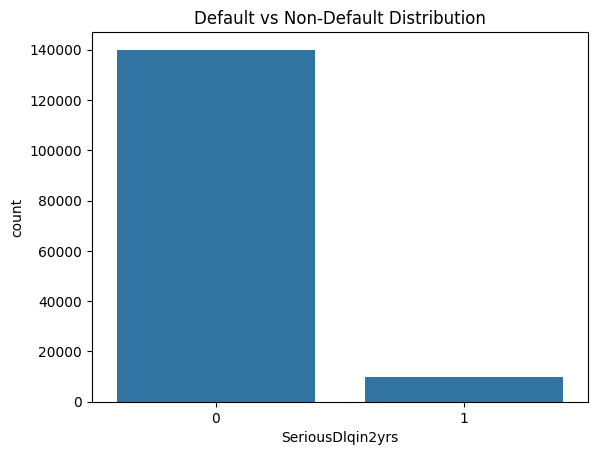

In [ ]:
# TARGET DISTRIBUTIONS[ON COLUMN SeriousDlqin2yrs]
sns.countplot(x='SeriousDlqin2yrs',data=data)
plt.title("Default vs Non-Default Distribution")
plt.show()

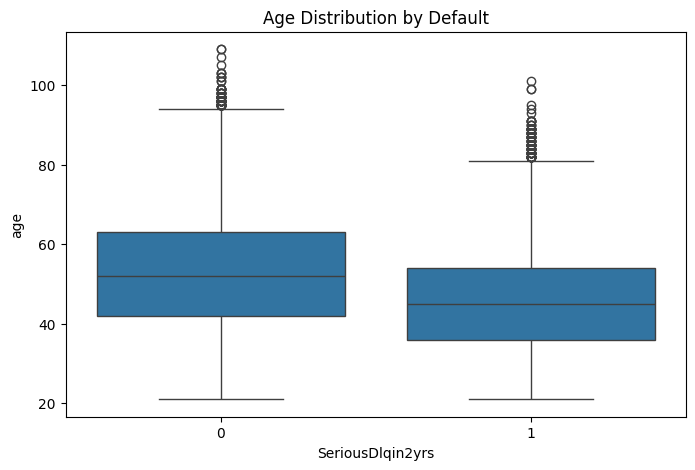

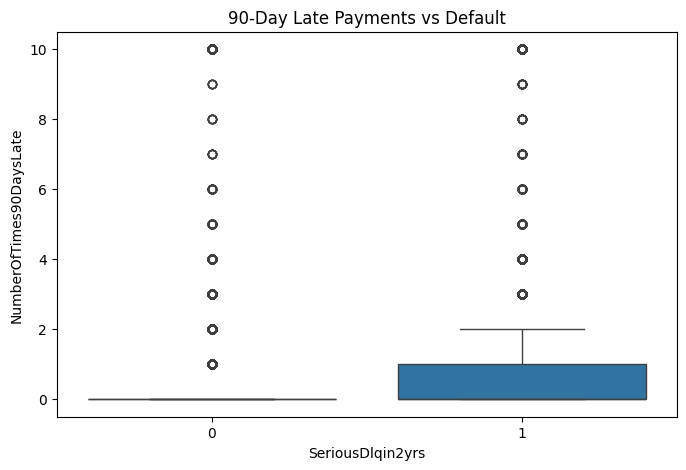

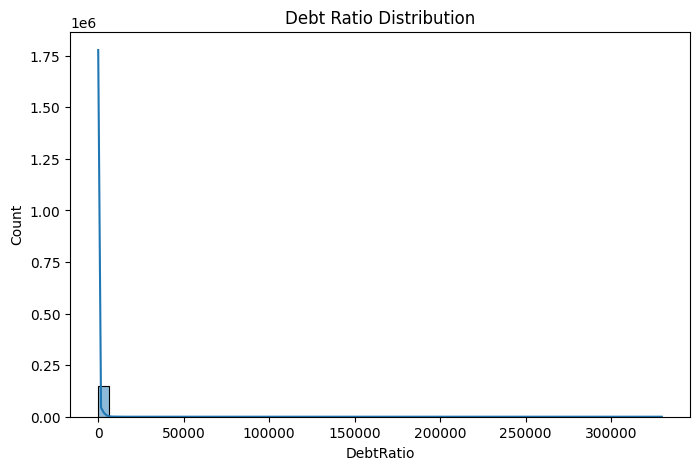

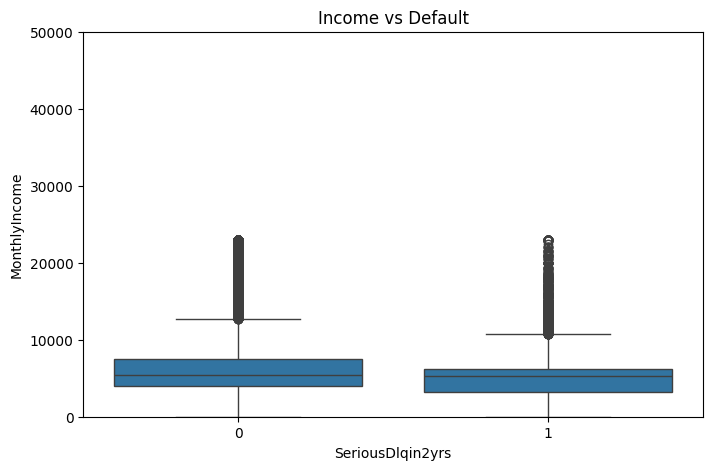

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='SeriousDlqin2yrs', y='age', data=data)
plt.title("Age Distribution by Default")
plt.show()


plt.figure(figsize=(8,5))
sns.boxplot(x='SeriousDlqin2yrs',
            y='NumberOfTimes90DaysLate',
            data=data)
plt.title("90-Day Late Payments vs Default")
plt.show()


plt.figure(figsize=(8,5))
sns.histplot(data['DebtRatio'], bins=50, kde=True)
plt.title("Debt Ratio Distribution")
plt.show()


plt.figure(figsize=(8,5))
sns.boxplot(x='SeriousDlqin2yrs',
            y='MonthlyIncome',
            data=data)
plt.ylim(0, 50000)
plt.title("Income vs Default")
plt.show()

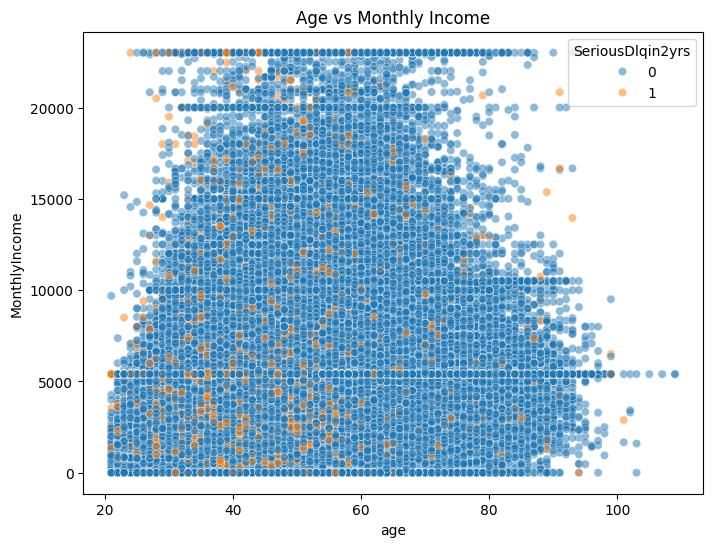

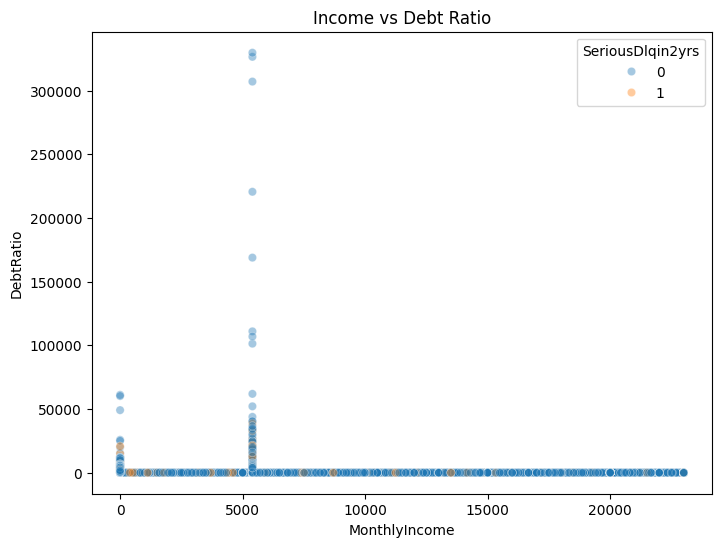

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='age', y='MonthlyIncome',
                hue='SeriousDlqin2yrs',
                data=data, alpha=0.5)

plt.title("Age vs Monthly Income")
plt.show()


plt.figure(figsize=(8,6))
sns.scatterplot(x='MonthlyIncome',
                y='DebtRatio',
                hue='SeriousDlqin2yrs',
                data=data,
                alpha=0.4)

plt.title("Income vs Debt Ratio")
plt.show()

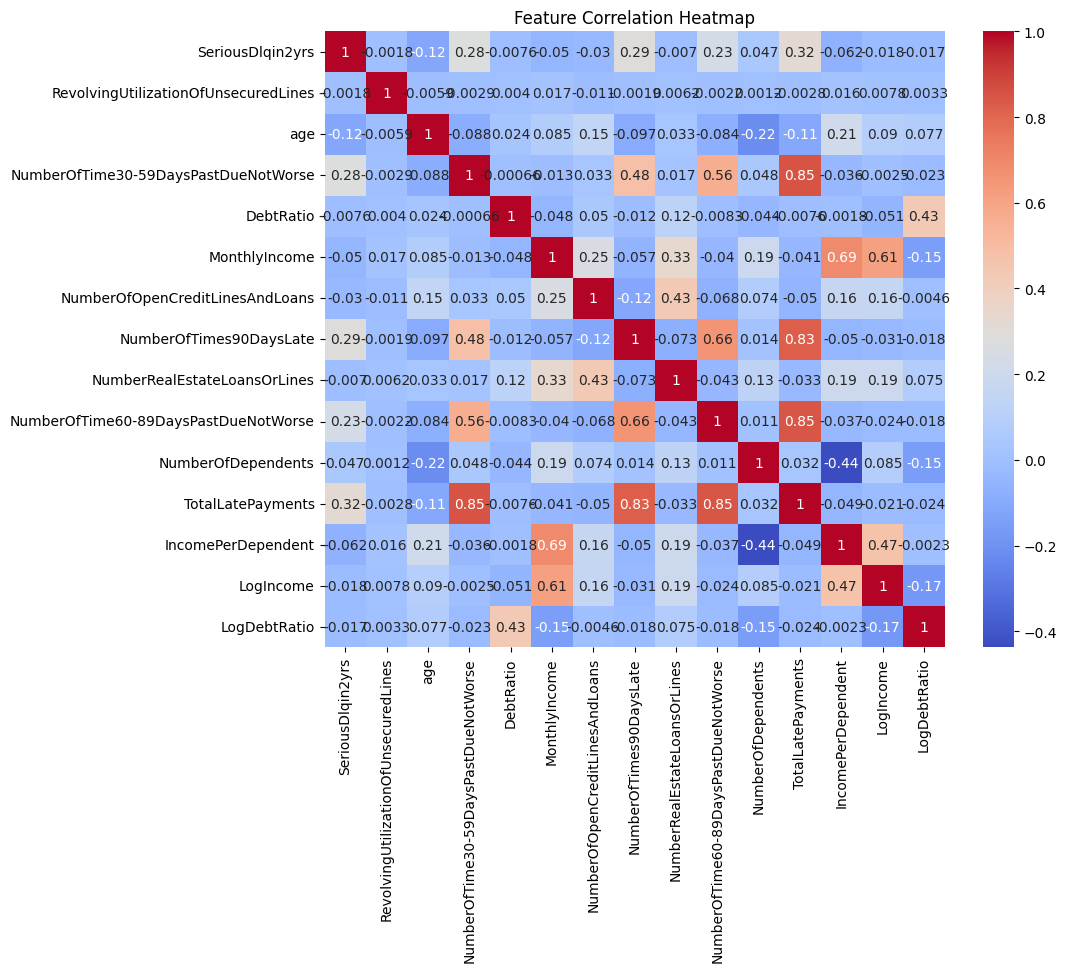

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

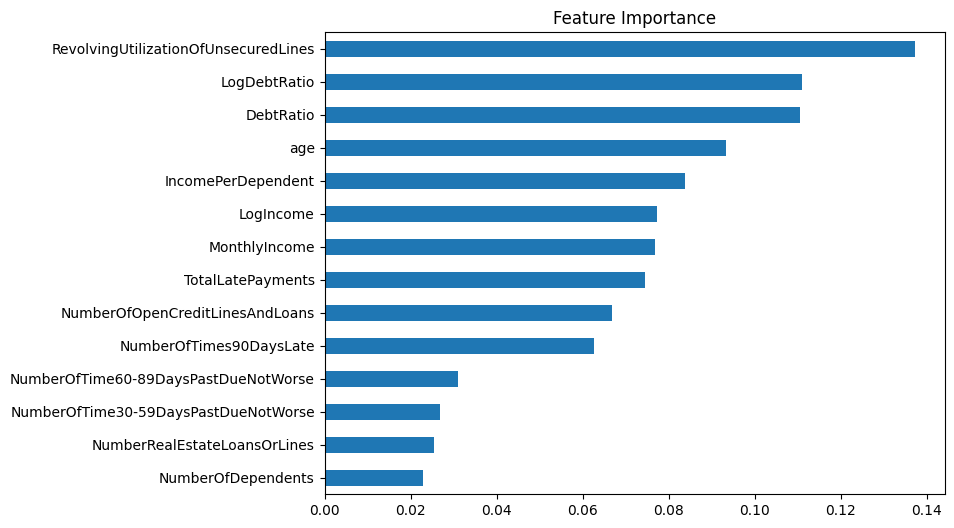

In [ ]:
from sklearn.ensemble import RandomForestClassifier

X = data.drop('SeriousDlqin2yrs', axis=1)
y = data['SeriousDlqin2yrs']

rf = RandomForestClassifier()
rf.fit(X, y)

importance = pd.Series(rf.feature_importances_,
                       index=X.columns)

importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.show()

## OUT-LIER TREATMENT

In [ ]:
data = data[data['MonthlyIncome'] >= 0]

# Apply only upper cap
upper_income = data['MonthlyIncome'].quantile(0.99)
data['MonthlyIncome'] = data['MonthlyIncome'].clip(upper=upper_income)


data = data[data['age'] >= 18]

In [ ]:
cols = [
    'NumberOfTimes90DaysLate',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

for col in cols:
    data[col] = data[col].clip(upper=10)

In [ ]:
#### FEATURE ENGINEERING
data['TotalLatePayments'] = (
    data['NumberOfTimes90DaysLate'] +
    data['NumberOfTime30-59DaysPastDueNotWorse'] +
    data['NumberOfTime60-89DaysPastDueNotWorse']
)


data['IncomePerDependent'] = data['MonthlyIncome'] / (data['NumberOfDependents'] + 1)

data['LogIncome'] = np.log1p(data['MonthlyIncome'])
data['LogDebtRatio'] = np.log1p(data['DebtRatio'])

In [ ]:
data

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,TotalLatePayments,IncomePerDependent,LogIncome,LogDebtRatio
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,2,3040.000000,9.118335,0.589442
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0,1300.000000,7.863651,0.115002
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,2,3042.000000,8.020599,0.081684
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0,3300.000000,8.101981,0.035415
4,0,0.907239,49,1,0.024926,23000.0,7,0,1,0,0.0,1,23000.000000,10.043293,0.024620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0,0,2100.000000,7.650169,0.203048
149996,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0,0,1861.333333,8.627840,0.540324
149997,0,0.246044,58,0,3870.000000,5400.0,18,0,1,0,0.0,0,5400.000000,8.594339,8.261268
149998,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0,0,5716.000000,8.651199,0.000000


In [ ]:
##### As multi colinearity is present between late payments as we have introduced new feature as totallatepayments we can drop the remaing columns
data.drop(columns=['NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse'])

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfDependents,TotalLatePayments,IncomePerDependent,LogIncome,LogDebtRatio
0,1,0.766127,45,0.802982,9120.0,13,0,6,2.0,2,3040.000000,9.118335,0.589442
1,0,0.957151,40,0.121876,2600.0,4,0,0,1.0,0,1300.000000,7.863651,0.115002
2,0,0.658180,38,0.085113,3042.0,2,1,0,0.0,2,3042.000000,8.020599,0.081684
3,0,0.233810,30,0.036050,3300.0,5,0,0,0.0,0,3300.000000,8.101981,0.035415
4,0,0.907239,49,0.024926,23000.0,7,0,1,0.0,1,23000.000000,10.043293,0.024620
...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,0,0.040674,74,0.225131,2100.0,4,0,1,0.0,0,2100.000000,7.650169,0.203048
149996,0,0.299745,44,0.716562,5584.0,4,0,1,2.0,0,1861.333333,8.627840,0.540324
149997,0,0.246044,58,3870.000000,5400.0,18,0,1,0.0,0,5400.000000,8.594339,8.261268
149998,0,0.000000,30,0.000000,5716.0,4,0,0,0.0,0,5716.000000,8.651199,0.000000


#MODEL BUILDING AND EVALUCATION OF SUPERVIZED MODELS

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
X=data.drop('SeriousDlqin2yrs',axis=1)
y=data['SeriousDlqin2yrs']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler = MinMaxScaler()
X_train_norm=scaler.fit_transform(X_train)
X_test_norm=scaler.transform(X_test)

In [ ]:
### LOGISTIC REGRESSION ###
from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression()
log_model.fit(X_train_norm,y_train)
training_acc=log_model.score(X_train_norm,y_train)
print("Training accuracy of logisticregression",training_acc)


log_test_pred=log_model.predict(X_test_norm)
testing_acc=accuracy_score(y_test,log_test_pred)
print("Testing accuarcy of logisticregression",testing_acc)

Training accuracy of logisticregression 0.9357161309677581
Testing accuarcy of logisticregression 0.9365


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_train_prob = log_model.predict_proba(X_train_norm)[:,1]
y_test_prob = log_model.predict_proba(X_test_norm)[:,1]

train_auc=roc_auc_score(y_train,y_train_prob)
test_auc=roc_auc_score(y_test,y_test_prob)

print("Training AUC:", train_auc)
print("Testing AUC:", test_auc)

Training AUC: 0.8062344264464061
Testing AUC: 0.7990171414390861


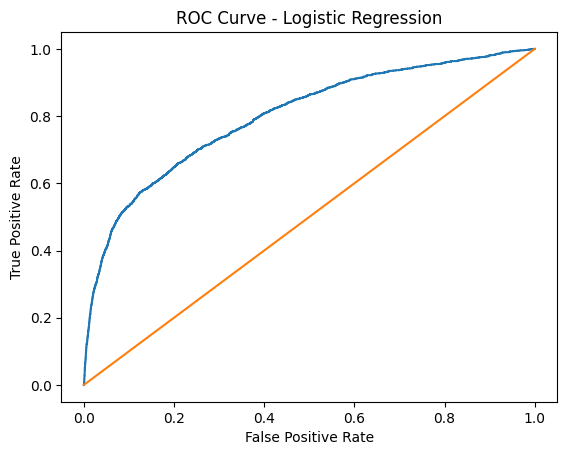

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.show()

In [ ]:
### RANDOM FOREST ###
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(n_estimators=100,max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,random_state=42)

rf_model.fit(X_train,y_train)
train_acc_rf=rf_model.score(X_train,y_train)
print("training accuracy of randomforset",train_acc_rf)

test_acc_rf = rf_model.score(X_test, y_test)
print("Testing Accuracy:", test_acc_rf)

training accuracy of randomforset 0.9405745047875399
Testing Accuracy: 0.9376


In [ ]:
y_train_prob_rf=rf_model.predict_proba(X_train)[:,1]
y_test_prob_rf=rf_model.predict_proba(X_test)[:,1]

train_rf_auc=roc_auc_score(y_train,y_train_prob_rf)
test_rf_auc=roc_auc_score(y_test,y_test_prob_rf)

print("Training AUC of randomforest:", train_rf_auc)
print("Testing AUC of randomforest:", test_rf_auc)

Training AUC of randomforest: 0.8753720836971886
Testing AUC of randomforest: 0.8563617257811381


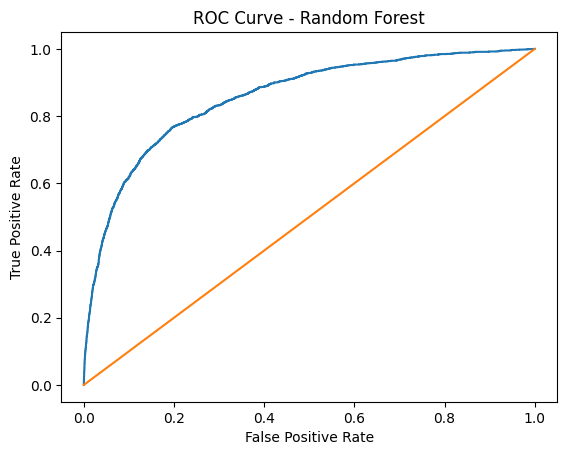

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob_rf)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")

plt.show()

In [ ]:
### XGBOOST ###
!pip install --upgrade scikit-learn xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 23.2 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [ ]:
 import xgboost as xgb
 from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
 def evaluate_model(model, X_val, y_val, model_name):
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    print(classification_report(y_val, y_pred))
    sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

              precision    recall  f1-score   support

           0       0.95      0.99      0.97     28041
           1       0.52      0.20      0.29      1959

    accuracy                           0.94     30000
   macro avg       0.73      0.60      0.63     30000
weighted avg       0.92      0.94      0.92     30000



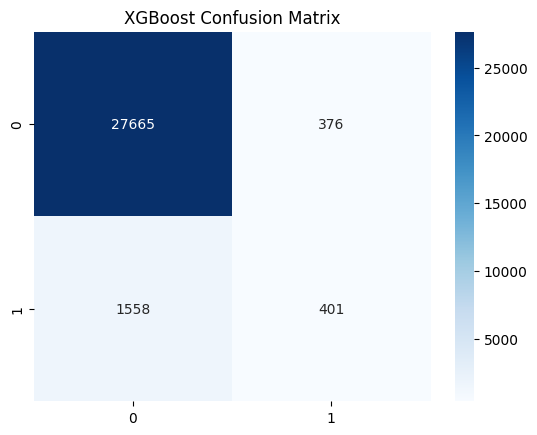

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     28041
           1       0.58      0.16      0.25      1959

    accuracy                           0.94     30000
   macro avg       0.76      0.57      0.61     30000
weighted avg       0.92      0.94      0.92     30000



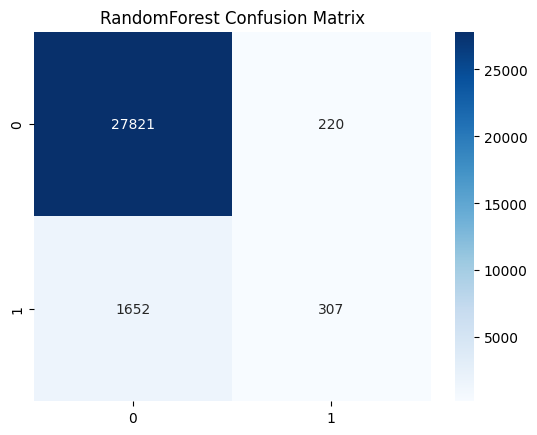

              precision    recall  f1-score   support

           0       0.93      1.00      0.97     28041
           1       0.20      0.00      0.00      1959

    accuracy                           0.93     30000
   macro avg       0.57      0.50      0.48     30000
weighted avg       0.89      0.93      0.90     30000



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


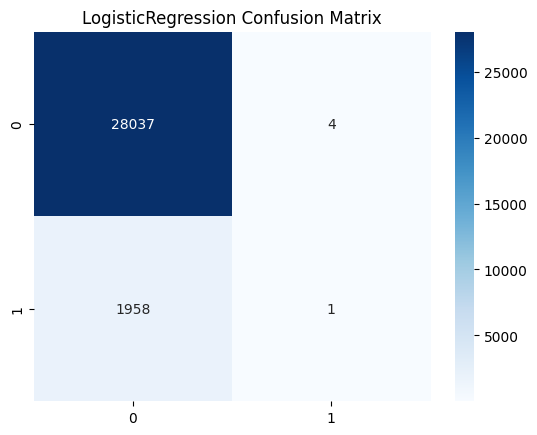

In [ ]:
xgb_model = xgb.XGBClassifier(random_state=42,)
xgb_model.fit(X_train, y_train)
xgb_model_results = evaluate_model(xgb_model, X_test, y_test, "XGBoost")

rf_model_result = evaluate_model(rf_model, X_test, y_test,"RandomForest")

log_model_result = evaluate_model(log_model, X_test, y_test,"LogisticRegression")

In [ ]:
y_train_prob_xgb = xgb_model.predict_proba(X_train)[:,1]
train_auc_xgb = roc_auc_score(y_train, y_train_prob_xgb)
print("Training AUC of XGBoost:", train_auc_xgb)

y_test_prob_xgb = xgb_model.predict_proba(X_test)[:,1]
test_auc_xgb = roc_auc_score(y_test,y_test_prob_xgb)
print("Testing AUC of XGBoost:",test_auc_xgb)

Training AUC of XGBoost: 0.9195927490304826
Testing AUC of XGBoost: 0.8498089985969826


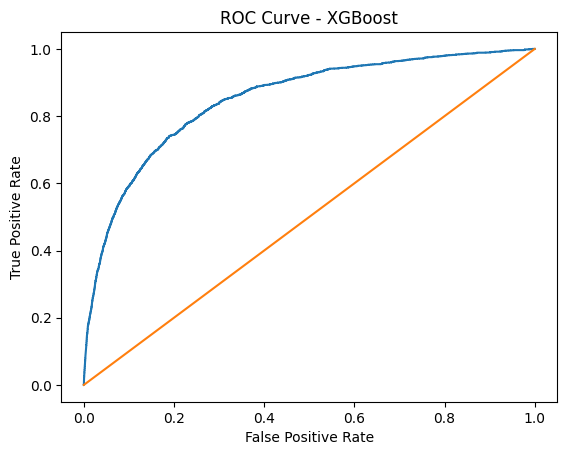

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob_xgb)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")

plt.show()

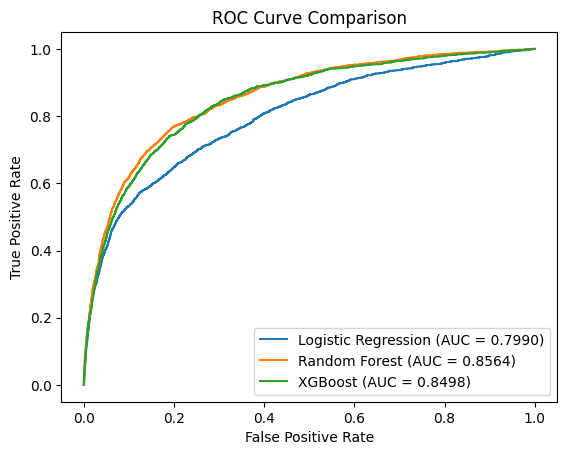

Logistic Regression AUC: 0.7990171414390861
Random Forest AUC: 0.8563617257811381
XGBoost AUC: 0.8498089985969826


In [ ]:
### FINAL COMPARSION OF ALL THREE MODELS LOGISTICREGRESSION,RANDOMFOREST,XGBOOST ###
log_fpr,log_tpr,_ = roc_curve(y_test,y_test_prob)
plt.plot(log_fpr, log_tpr, label=f"Logistic Regression (AUC = {test_auc:.4f})")

rf_fpr,rf_tpr,_ = roc_curve(y_test,y_test_prob_rf)
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {test_rf_auc:.4f})")

xgb_fpr,xgb_tpr,_ = roc_curve(y_test,y_test_prob_xgb)
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {test_auc_xgb:.4f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

print("Logistic Regression AUC:", test_auc)
print("Random Forest AUC:", test_rf_auc)
print("XGBoost AUC:", test_auc_xgb)

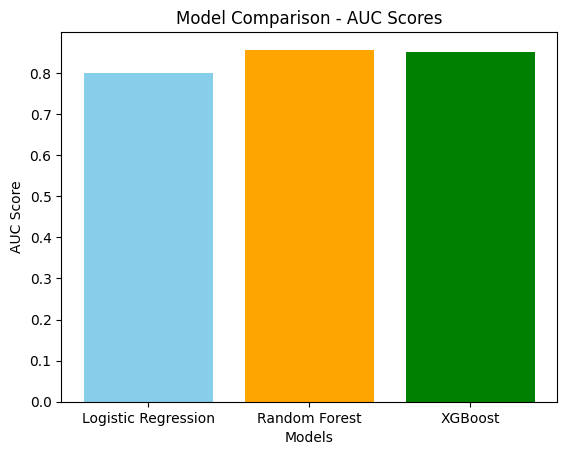

In [ ]:
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
auc_scores = [test_auc, test_rf_auc, test_auc_xgb]

colors = ['skyblue', 'orange', 'green']

bars = plt.bar(models, auc_scores, color=colors)

plt.xlabel("Models")
plt.ylabel("AUC Score")
plt.title("Model Comparison - AUC Scores")

plt.show()


#ARTIFICIAL NEURAL NETWORKS[ANN]

In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_norm.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['AUC'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV

mlp = MLPClassifier(
    max_iter=150,
    early_stopping=True,
    random_state=42
)

param_dist = {
    'hidden_layer_sizes': [(32,), (64,), (64,32)],
    'alpha': [0.0001, 0.001],
    'learning_rate_init': [0.001, 0.005]
}

random_search = RandomizedSearchCV(
    mlp,
    param_distributions=param_dist,
    n_iter=5,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train_norm, y_train)

print("Best Params:", random_search.best_params_)
print("Best CV AUC:", random_search.best_score_)


random_search.fit(X_train_norm, y_train)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Params: {'learning_rate_init': 0.005, 'hidden_layer_sizes': (64, 32), 'alpha': 0.0001}
Best CV AUC: 0.8329279820616385
Fitting 3 folds for each of 5 candidates, totalling 15 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPClassifier...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'alpha': [0.0001, 0.001], 'hidden_layer_sizes': [(32,), (64,), ...], 'learning_rate_init': [0.001, 0.005]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 

In [ ]:
best_mlp = random_search.best_estimator_

y_test_prob_ann = best_mlp.predict_proba(X_test_norm)[:, 1]
test_auc_ann = roc_auc_score(y_test, y_test_prob_ann)

print("Final ANN (MLP) Test AUC:", test_auc_ann)

Final ANN (MLP) Test AUC: 0.830737812106567


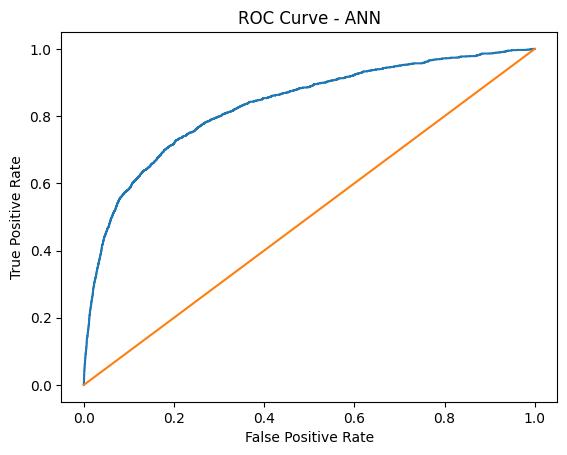

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob_ann)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ANN")

plt.show()

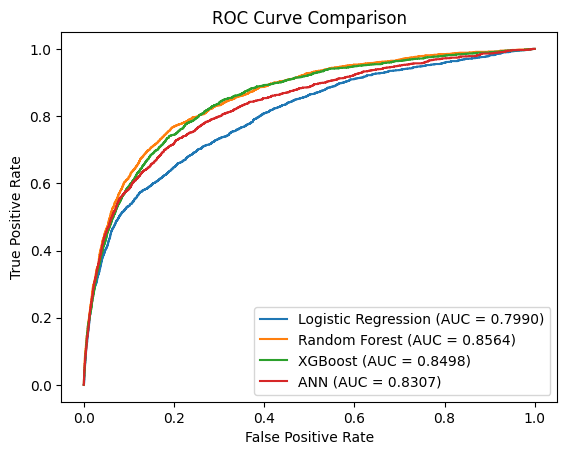

Logistic Regression AUC: 0.7990171414390861
Random Forest AUC: 0.8563617257811381
XGBoost AUC: 0.8498089985969826
ANN AUC: 0.830737812106567


In [ ]:
log_fpr,log_tpr,_ = roc_curve(y_test,y_test_prob)
plt.plot(log_fpr, log_tpr, label=f"Logistic Regression (AUC = {test_auc:.4f})")

rf_fpr,rf_tpr,_ = roc_curve(y_test,y_test_prob_rf)
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {test_rf_auc:.4f})")

xgb_fpr,xgb_tpr,_ = roc_curve(y_test,y_test_prob_xgb)
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {test_auc_xgb:.4f})")

ann_fpr,ann_tpr,_ = roc_curve(y_test,y_test_prob_ann)
plt.plot(ann_fpr,ann_tpr,label=f"ANN (AUC = {test_auc_ann:.4f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

print("Logistic Regression AUC:", test_auc)
print("Random Forest AUC:", test_rf_auc)
print("XGBoost AUC:", test_auc_xgb)
print("ANN AUC:", test_auc_ann)

In [ ]:
pip install shap

In [ ]:
import shap
explainer=shap.Explainer(best_mlp.predict_proba,X_train_norm)

shap_values=explainer(X_test_norm[:1000])

PermutationExplainer explainer: 1001it [01:03, 15.42it/s]                          


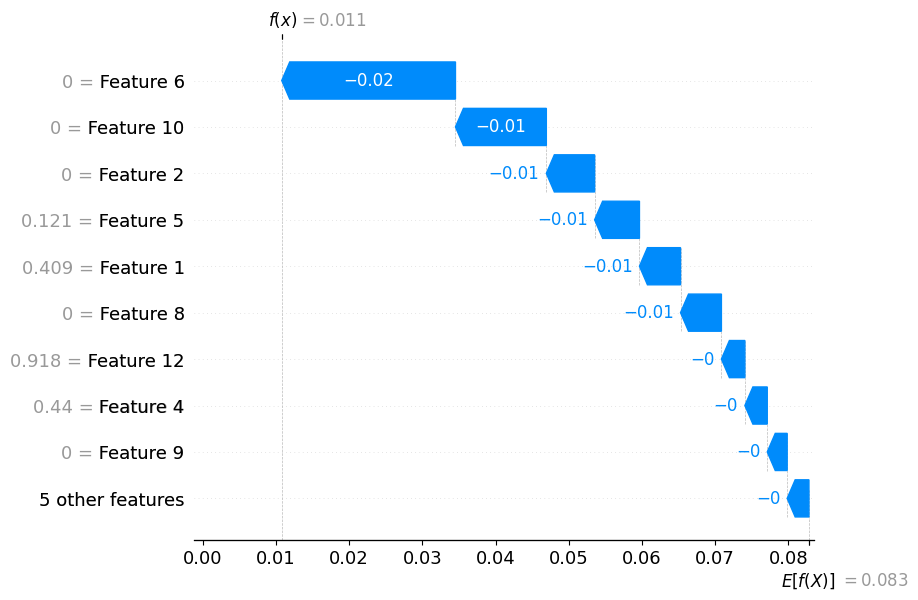

In [ ]:
shap.plots.waterfall(shap_values[0,:,1])

/tmp/ipython-input-2455121385.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


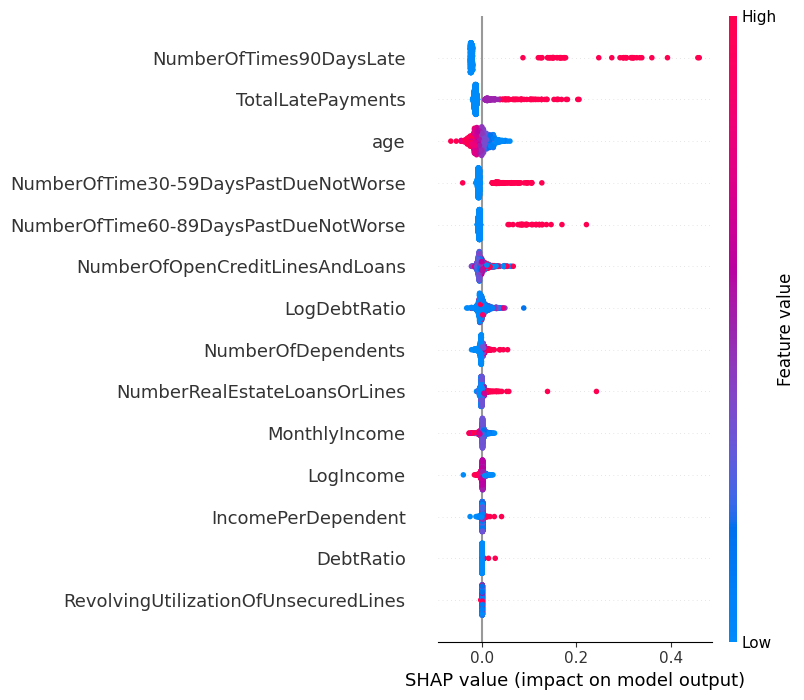

In [ ]:
shap.summary_plot(
    shap_values[:,:,1],
    X_test_norm[:1000],
    feature_names=X_train.columns
)